Found 19840 images belonging to 10 classes.
Found 4960 images belonging to 10 classes.
Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d_21 (Conv2D)          (None, 64, 64, 16)        448       
                                                                 
 batch_normalization_4 (Bat  (None, 64, 64, 16)        64        
 chNormalization)                                                
                                                                 
 activation_4 (Activation)   (None, 64, 64, 16)        0         
                                                                 
 max_pooling2d_21 (MaxPooli  (None, 32, 32, 16)        0         
 ng2D)                                                           
                                      

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


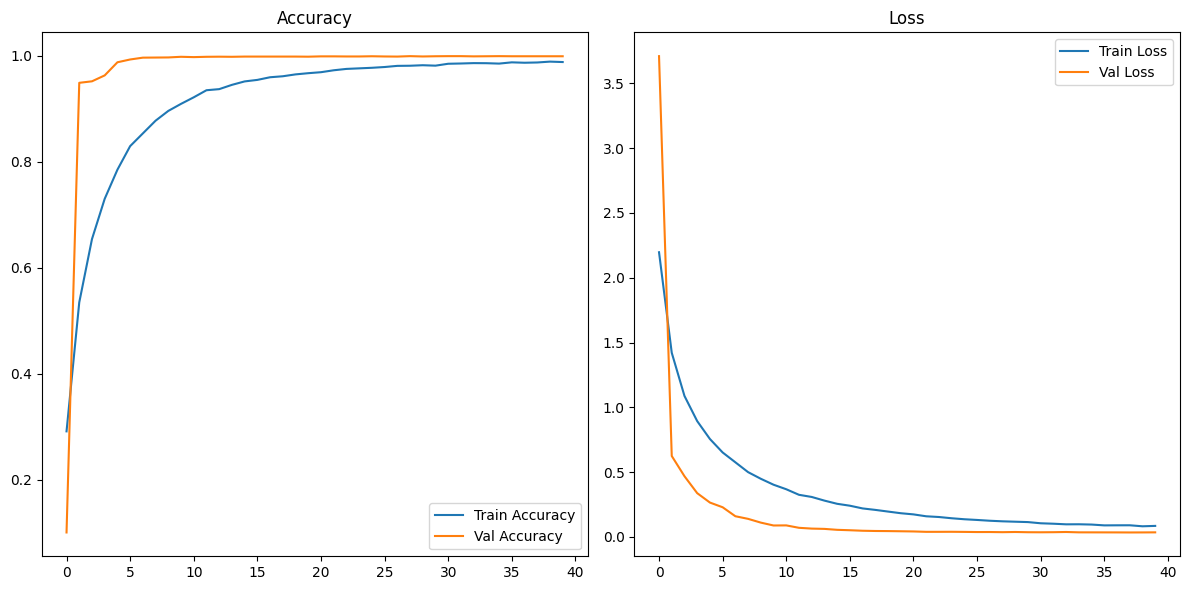

77/77 [==============================] - 8s 100ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       496
           1       1.00      1.00      1.00       496
           2       1.00      1.00      1.00       496
           3       1.00      1.00      1.00       496
           4       1.00      1.00      1.00       496
           5       1.00      1.00      1.00       496
           6       1.00      1.00      1.00       496
           7       1.00      1.00      1.00       496
           8       1.00      1.00      1.00       496
           9       0.99      1.00      1.00       464

    accuracy                           1.00      4928
   macro avg       1.00      1.00      1.00      4928
weighted avg       1.00      1.00      1.00      4928

Accuracy:  0.9992
Precision: 0.9992
Recall:    0.9992
F1 Score:  0.9992


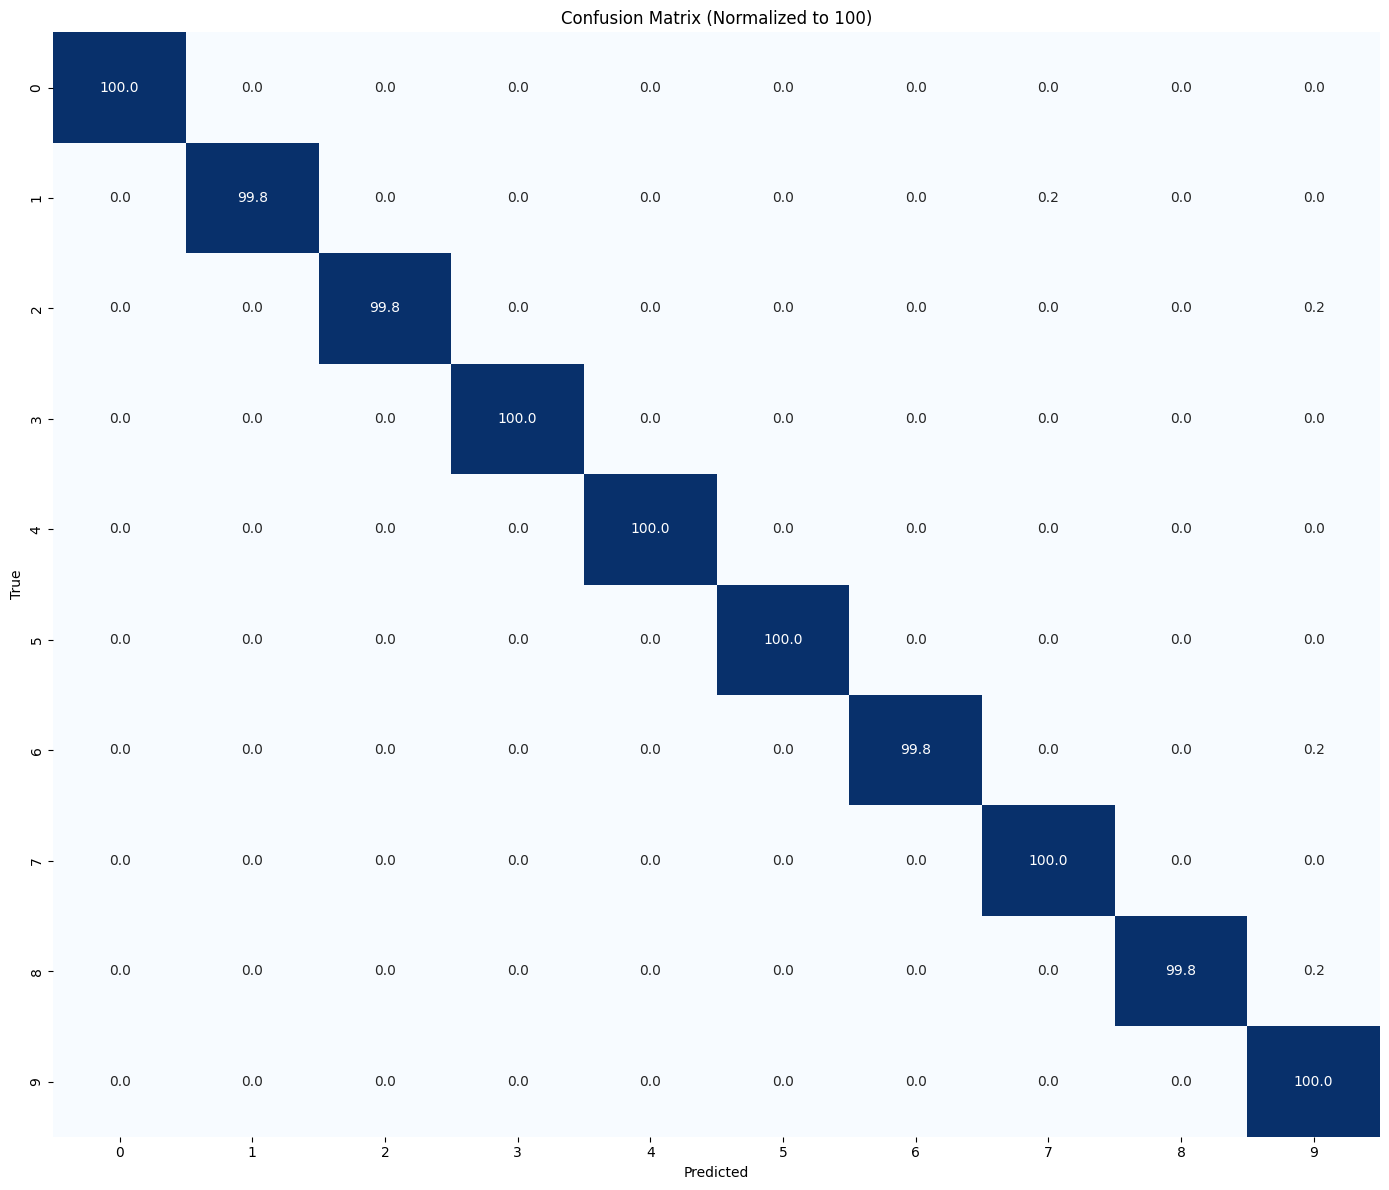

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, regularizers, callbacks
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import tensorflow as tf
import random

# For reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# -------- CNN Model Definition with BatchNorm and L2 Regularization --------
def build_cnn_model(input_shape=(64, 64, 3), num_classes=10):
    weight_decay = 1e-4
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(16, (3, 3), padding='same', kernel_regularizer=regularizers.l2(weight_decay))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(128, kernel_regularizer=regularizers.l2(weight_decay))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.6)(x)  # stronger dropout
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# -------- Data Generators with Extensive Augmentation (for Train) --------
train_dir = r'E:\cnndatasets\numbers_dataset\train'
val_dir = r'E:\cnndatasets\numbers_dataset\val'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,  # keep False if digits orientation matters
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # validation no augmentation other than rescale

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(64, 64),
    batch_size=64,
    class_mode='categorical',
    shuffle=False,  # important for correct matching in metrics
    seed=42
)

# -------- Build and Compile Model --------
model = build_cnn_model(input_shape=(64, 64, 3), num_classes=10)
model.summary()
plot_model(model, to_file='model_structure.png', show_shapes=True, show_layer_names=True)

optimizer = Adam(learning_rate=0.00005)  # low lr to fine-tune slowly
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# -------- Callbacks --------
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)

# -------- Train the Model --------
history = model.fit(
    train_generator,
    epochs=40,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -------- Save Model --------
model.save('numeral_cnn_model.h5')

# -------- Plot Training History --------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('numeral_cnn_training_plot.png')
plt.show()

# -------- Evaluation --------
val_steps = val_generator.samples // val_generator.batch_size
y_true = val_generator.classes[:val_steps * val_generator.batch_size]
y_pred = np.argmax(model.predict(val_generator, steps=val_steps), axis=-1)

print("Classification Report:\n", classification_report(y_true, y_pred))
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")

# -------- Confusion Matrix --------
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    xticklabels=list(val_generator.class_indices.keys()),
    yticklabels=list(val_generator.class_indices.keys()),
    cbar=False
)
plt.title("Confusion Matrix (Normalized to 100)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png')
plt.show()


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import textwrap

# Define batch size (must match training)
batch_size = 64
val_path = r'E:\cnndatasets\numbers_dataset\val'
datagen_val = ImageDataGenerator(rescale=1./255)
val_generator = datagen_val.flow_from_directory(
    val_path,
    target_size=(64, 64),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Helper function -- renders multiline monospaced text using matplotlib for crisp output
def save_text_matplotlib(text, filename, font_size=14, line_width=120, dpi=300, pad=0.02):
    lines = []
    for l in text.split('\n'):
        lines.extend(textwrap.wrap(l, width=line_width) or [" "])
    n_lines = len(lines)
    height_per_line = font_size * 1.5 / dpi  # Height in inches per line
    fig_height = height_per_line * n_lines + pad
    fig_width = min(max(len(max(lines, key=len)) * (font_size/12) * 0.09, 8), 48)
    plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    plt.axis('off')
    plt.figtext(0, 1-pad, "\n".join(lines), wrap=True,
                fontfamily='monospace', fontsize=font_size, va="top", ha="left")
    plt.savefig(filename, bbox_inches='tight', dpi=dpi, pad_inches=pad, transparent=False)
    plt.close()

# Save model summary as readable image
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))
summary_str = stream.getvalue()
save_text_matplotlib(summary_str, 'CNN_model_structure2.png', font_size=13, line_width=130)

# Generate predictions etc.
val_steps = val_generator.samples // batch_size
y_pred_probs = model.predict(val_generator, steps=val_steps)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes[:len(y_pred)]
class_names = list(val_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification Report:\n", report)
save_text_matplotlib(report, 'CNN_classification_report.png', font_size=18, line_width=100)


Found 4960 images belonging to 10 classes.
77/77 [==============================] - 9s 114ms/step
Classification Report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       496
           1     1.0000    0.9980    0.9990       496
           2     1.0000    0.9980    0.9990       496
           3     1.0000    1.0000    1.0000       496
           4     1.0000    1.0000    1.0000       496
           5     1.0000    1.0000    1.0000       496
           6     1.0000    0.9980    0.9990       496
           7     0.9980    1.0000    0.9990       496
           8     1.0000    0.9980    0.9990       496
           9     0.9936    1.0000    0.9968       464

    accuracy                         0.9992      4928
   macro avg     0.9992    0.9992    0.9992      4928
weighted avg     0.9992    0.9992    0.9992      4928

